# Question 3: Insights and Use Cases

## Assignment
> On insights and use cases:
> - What first impressions do you get from this data?
> - Name three use cases for this dataset (assume you might also combine it with other public or Adevinta datasets).


## 1. Link With Question 2

Question 2 uses this dataset as an A/B testing problem: define the lead KPI, check whether A and B are comparable, estimate the result, and explain the risks around causal interpretation.

Question 3 uses the same data differently. The goal is not to prove whether the feature caused an uplift, but to ask what the car-ad data suggests about marketplace behavior and what business use cases it can support.

I reuse the q2 lead definition:

`has_any_lead = telclicks > 0 OR bids > 0 OR n_asq > 0 OR webclicks > 0`

I also reuse q2's caveat: descriptive patterns are useful for product and business thinking, but they are not causal claims unless supported by an experiment or a stronger modelling design.


In [1]:
from pathlib import Path
import sys
import importlib

import pandas as pd
from IPython.display import display

helper_dir = Path.cwd()
if not (helper_dir / "functions.py").exists():
    helper_dir = Path.cwd() / "assignments" / "data_analyst"
if str(helper_dir) not in sys.path:
    sys.path.insert(0, str(helper_dir))

import functions as helpers

helpers = importlib.reload(helpers)

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 80)
helpers.plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
raw_data = helpers.read_ab_test_data(helpers.DATA_PATH)

insight_data = raw_data.copy()
metric_columns = helpers.existing_columns(insight_data, helpers.METRIC_COLUMNS)
insight_data[metric_columns] = insight_data[metric_columns].fillna(0)
insight_data["has_any_lead"] = insight_data[metric_columns].gt(0).any(axis=1)
insight_data["total_leads"] = insight_data[metric_columns].sum(axis=1)
insight_data["car_age"] = insight_data["bouwjaar"].max() - insight_data["bouwjaar"]
insight_data = helpers.add_segments(insight_data)

ab_data, excluded_data = helpers.prepare_ab_data(raw_data)
segmented_ab_data = helpers.add_segments(ab_data)

print(f"Rows available for q3 insights: {len(insight_data):,}")
print(f"Rows assigned to A/B groups in q2: {len(ab_data):,}")
print(f"Rows not assigned to an A/B group: {len(excluded_data):,} ({len(excluded_data) / len(raw_data):.1%})")


Rows available for q3 insights: 183,062
Rows assigned to A/B groups in q2: 174,449
Rows not assigned to an A/B group: 8,613 (4.7%)


The q2 notebook already established a few foundations that I do not need to repeat in detail here: most rows can be used for the A/B comparison, a small share have missing group assignment, duplicate ad IDs are rare, and B has a higher observed lead rate than A. For q3, the useful carry-over is mainly the lead KPI and the warning that group-level experiment findings should stay separate from broader descriptive insights.


How q3 uses q2:

- **Lead KPI:** reuse the same binary lead indicator as the main marketplace-interest outcome.
- **Data caveats:** keep missing group rows and duplicate IDs in mind, but do not let test-assignment issues dominate q3.
- **A/B result:** mention only as context; q3 is not another A/B readout.
- **Interpretation boundary:** treat q3 patterns as descriptive unless a later experiment or model supports causality.


## 2. First Impressions

This section intentionally starts broad. The aim is to collect the most plausible first impressions, then later narrow to the ones that are most interesting and presentation-worthy.


### 2.1 Marketplace Funnel Shape

The dataset is strongest around buyer interest in live ads. It measures whether an ad generated leads, but it does not show the full marketplace funnel from search exposure to sale.


What the dataset covers:

- **Ad/listing attributes:** useful for listing optimization and descriptive lead analysis.
- **Vehicle attributes:** useful for segmenting demand by car type, though not enough to estimate final value.
- **Lead outcomes:** a good proxy for buyer interest, but not guaranteed conversion.
- **Experiment group assignment:** useful for q2, but not the main focus of q3.

What it does not cover:

- Search impressions or ranking position.
- Seller history and seller quality.
- Buyer identity or buyer journey.
- Final sale, sale price, revenue, margin, or lead quality.

This means the dataset is strong for understanding lead generation, but it needs additional funnel and commercial data before making ROI or transaction-success claims.


### 2.2 Seller-Level Opportunity

The current car-ad dataset is ad-level only: it has `src_ad_id`, but no seller or account identifier. That means we cannot aggregate lead performance by seller, identify SMB sellers, or directly target sellers from this dataset alone.

A valuable extension would be to join this car-ad dataset to a seller/account dataset. With a seller ID, Marktplaats could identify SMB sellers with patterns such as:

- many active car ads but low lead performance;
- many stale listings that may need renewal, pricing, or visibility support;
- strong organic lead potential but low usage of premium products;
- high-volume sellers in high-demand vehicle segments.

Business opportunity: use the combined view to single out SMB sellers who are likely to benefit from premium services, then offer targeted visibility products, bundles, or listing-quality recommendations.


### 2.3 Lead Channel Mix

The four lead fields may represent different buyer intent. A website click, phone click, bid, and seller question are all leads, but they probably do not have the same commercial meaning.


,Channel,Rows With Event,Share of Ads With Event,Average Events Per Ad,Share of All Lead Events
3,Web Clicks,"97,931",0.535,2.739,0.514
2,Questions,"60,485",0.330,0.991,0.186
0,Tel Clicks,"57,429",0.314,0.917,0.172
1,Bids,"30,908",0.169,0.678,0.127


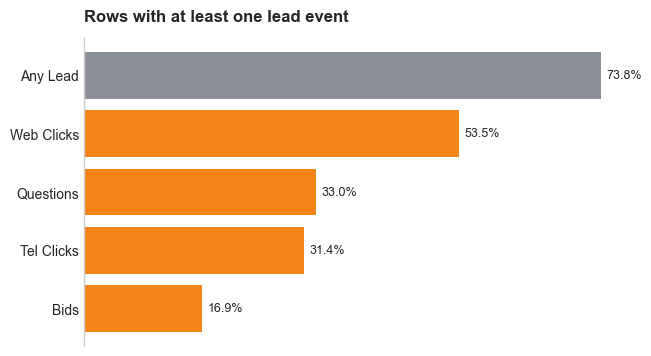

In [3]:
channel_mix = []
for column in helpers.METRIC_COLUMNS:
    channel_mix.append(
        {
            "channel": helpers.DISPLAY_VALUE_ALIASES.get(column, column),
            "rows_with_event": int(insight_data[column].gt(0).sum()),
            "share_of_ads_with_event": insight_data[column].gt(0).mean(),
            "average_events_per_ad": insight_data[column].mean(),
            "share_of_all_lead_events": insight_data[column].sum() / insight_data[helpers.METRIC_COLUMNS].sum().sum(),
        }
    )
channel_mix = pd.DataFrame(channel_mix).sort_values("share_of_all_lead_events", ascending=False)

display(helpers.style_table(channel_mix))
helpers.plot_lead_channel_coverage(insight_data)
helpers.plt.show()


This is useful beyond q2 because channel mix can shape product decisions. If channels behave differently, a single `has_any_lead` KPI is good for a headline view but not enough for understanding lead quality or seller value.


### 2.4 Skew and Concentration

Lead generation is likely concentrated: many ads get some interest, while a smaller group receives a large number of total leads. That matters because averages can overstate the typical seller experience.



Key figures:

- **73.8%** of ads have at least one lead.
- The median ad has **2** total leads.
- The 90th percentile has **14** leads; the 99th percentile has **40**.
- Top-decile ads generate **48.7%** of all lead events.


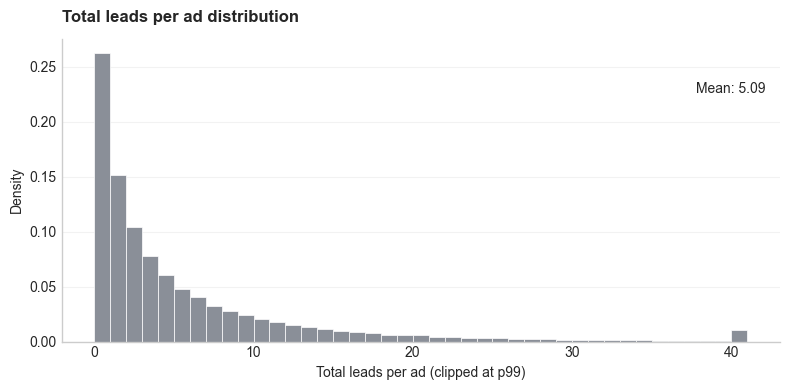

In [4]:
from IPython.display import Markdown

top_10_cutoff = insight_data["total_leads"].quantile(0.90)
top_10 = insight_data.loc[insight_data["total_leads"] >= top_10_cutoff]

lead_share = insight_data["has_any_lead"].mean()
median_leads = insight_data["total_leads"].median()
p90_leads = insight_data["total_leads"].quantile(0.90)
p99_leads = insight_data["total_leads"].quantile(0.99)
top_decile_lead_share = top_10["total_leads"].sum() / insight_data["total_leads"].sum()

display(Markdown(f"""
Key figures:

- **{lead_share:.1%}** of ads have at least one lead.
- The median ad has **{median_leads:.0f}** total leads.
- The 90th percentile has **{p90_leads:.0f}** leads; the 99th percentile has **{p99_leads:.0f}**.
- Top-decile ads generate **{top_decile_lead_share:.1%}** of all lead events.
"""))

helpers.plot_total_leads_distribution(insight_data.loc[insight_data["group"].isin(["A", "B"])] )
helpers.plt.show()


- Lead volume is highly skewed: many ads receive few leads, while a small group receives many.
- Business implication: use median, percentile, and concentration views alongside averages.
- This helps separate typical seller experience from high-performing outliers.

### 2.5 Listing Quality Signals

Some fields describe how the ad is presented rather than what the car is. These are interesting because sellers or Marktplaats can potentially influence them.


,Photo Count Band,Ads,Lead Rate,Avg Leads/Ad,Median Days Live,Median Price,Share of Ads
0,0-5,"8,630",0.797,8.092,31.000,"18,500.000",0.047
1,6-12,"61,208",0.816,6.968,31.000,"29,000.000",0.334
2,13-20,"57,750",0.730,4.934,31.000,"59,950.000",0.315
3,21+,"55,474",0.650,3.488,31.000,"117,450.000",0.303


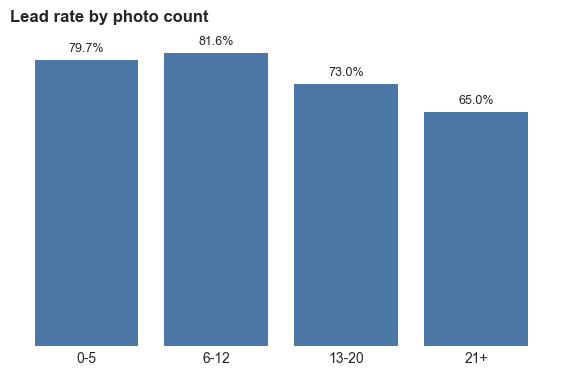

In [5]:
listing_quality = (
    insight_data.dropna(subset=["photo_count_band"])
    .groupby("photo_count_band", observed=True)
    .agg(
        ads=("src_ad_id", "count"),
        lead_rate=("has_any_lead", "mean"),
        avg_total_leads=("total_leads", "mean"),
        median_days_live=("days_live", "median"),
        median_price=("price", "median"),
    )
    .reset_index()
)
listing_quality["share_of_ads"] = listing_quality["ads"] / len(insight_data)

display(helpers.style_table(listing_quality))

fig, ax = helpers.plt.subplots(figsize=(7, 4))
helpers.plot_labeled_vertical_bars(
    ax,
    listing_quality["photo_count_band"].astype(str),
    listing_quality["lead_rate"],
    "Lead rate by photo count",
    ylabel="Lead rate",
    colors=helpers.PLOT_COLORS["A"],
    percent_y=True,
    percent_labels=True,
)
helpers.plt.show()


Photo count is especially practical: unlike brand, model, or mileage, it is a seller action. If the pattern is strong enough after controlling for car type and price, it could become seller guidance or an automated listing-quality recommendation.


### 2.6 Vehicle Attribute Demand Patterns

Vehicle fields are useful for understanding demand. They may not be directly changeable by sellers, but they help marketplace teams understand which segments attract more interest.


In [6]:
def segment_insight_summary(dataframe, segment_column, min_ads=500):
    summary = (
        dataframe.dropna(subset=[segment_column])
        .groupby(segment_column, observed=True)
        .agg(
            ads=("src_ad_id", "count"),
            lead_rate=("has_any_lead", "mean"),
            avg_total_leads=("total_leads", "mean"),
            median_price=("price", "median"),
            median_photos=("photo_cnt", "median"),
        )
        .reset_index()
    )
    summary = summary.loc[summary["ads"] >= min_ads].copy()
    summary["share_of_ads"] = summary["ads"] / len(dataframe)
    return summary.sort_values("lead_rate", ascending=False)

for segment_column in ["price_band", "km_band", "car_age_band"]:
    display(helpers.style_table(segment_insight_summary(insight_data, segment_column)))


,Price Band,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Share of Ads
0,0-25k,"52,340",0.885,8.689,"11,500.000",11.000,0.286
1,25k-60k,"42,250",0.799,5.815,"39,990.000",14.000,0.231
2,60k-120k,"43,290",0.664,3.524,"87,450.000",18.000,0.236
3,120k+,"45,175",0.580,2.694,"184,450.000",22.000,0.247


,Mileage Band,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Share of Ads
3,200k+,"45,272",0.860,7.167,"22,500.000",12.000,0.247
2,150k-200k,"35,863",0.825,6.583,"39,450.000",14.000,0.196
1,75k-150k,"56,374",0.748,5.117,"69,500.000",16.000,0.308
0,0-75k,"44,149",0.524,2.525,"139,000.000",20.000,0.241


,Car Age Band,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Share of Ads
3,13+,"50,442",0.877,8.113,"14,500.000",11.000,0.276
2,8-12,"52,457",0.815,6.184,"44,950.000",14.000,0.287
1,4-7,"45,914",0.695,3.941,"97,500.000",18.000,0.251
0,0-3,"34,249",0.470,1.757,"169,950.000",22.000,0.187


In [7]:
body_type_summary = segment_insight_summary(insight_data, "carrosserie", min_ads=1000).head(10)
brand_summary = segment_insight_summary(insight_data, "brand", min_ads=1000).head(10)

display(helpers.style_table(body_type_summary))
display(helpers.style_table(brand_summary))


,Body Type,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Share of Ads
1,Coup,"2,913",0.863,7.863,"89,500.000",17.000,0.016
5,Sedan (2/4-deurs),"15,472",0.841,7.035,"59,500.000",16.000,0.085
4,Overige carrosserie n,"2,494",0.769,5.712,"34,250.000",12.000,0.014
0,Cabriolet,"5,290",0.759,4.677,"69,900.000",17.000,0.029
6,Stationwagon,"29,233",0.742,4.709,"69,500.000",17.000,0.160
7,Terreinwagen,"10,128",0.729,4.649,"169,400.000",21.000,0.055
2,Hatchback (3/5-deurs),"79,944",0.719,5.614,"49,500.000",14.000,0.437
3,MPV,"19,737",0.692,3.879,"49,990.000",16.000,0.108


,Brand,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Photos,Share of Ads
12,AUDI,"7,062",0.845,6.658,"122,475.000",19.000,0.039
37,DAEWOO,"1,070",0.829,7.456,"9,995.000",10.000,0.006
40,DAIHATSU,"1,052",0.825,6.743,"19,500.000",12.000,0.006
3,ALFA ROMEO,"1,577",0.824,6.674,"44,950.000",15.000,0.009
187,VOLKSWAGEN,"22,148",0.803,6.862,"69,000.000",15.000,0.121
20,BMW,"9,259",0.801,6.919,"119,900.000",20.000,0.051
123,MERCEDES,"7,809",0.796,6.481,"124,500.000",18.000,0.043
165,SEAT,"4,906",0.794,5.771,"47,125.000",14.000,0.027
120,MAZDA,"2,398",0.784,5.169,"33,675.000",14.000,0.013
31,CHEVROLET,"1,513",0.767,5.743,"38,500.000",14.000,0.008


These segment views were too exploratory for the q2 A/B story, but they fit q3 well. They can support inventory planning, merchandising, seller education, and commercial targeting.


### 2.7 Time and Listing Lifecycle Signals

The time fields can add a useful lifecycle view: `ad_start_dt` tells us when ads started, while `days_live` approximates how long listings have been active. This can support seller advice and promotion timing, but there is an important caveat: all ad start dates in this file are in November 2016, so this is not enough for seasonality or long-term trend analysis.


In [8]:
time_scope = pd.DataFrame(
    {
        "metric": [
            "Earliest ad start",
            "Latest ad start",
            "Days live median",
            "Days live p90",
            "Days live max",
        ],
        "value": [
            insight_data["ad_start_dt"].min(),
            insight_data["ad_start_dt"].max(),
            insight_data["days_live"].median(),
            insight_data["days_live"].quantile(0.90),
            insight_data["days_live"].max(),
        ],
    }
)

display(helpers.style_table(time_scope))


,Metric,Value
0,Earliest ad start,2016-11-01
1,Latest ad start,2016-11-30
2,Days live median,31
3,Days live p90,31
4,Days live max,134


#### 2.7.1 Ad Lifecycle

A first lifecycle question is whether lead outcomes differ by how long an ad has been live. Older ads naturally have had more time to collect leads, so this is descriptive rather than causal.


,Days Live Band,Ads,Lead Rate,Avg Leads/Ad,Median Leads/Ad,Median Price,Median Photos,Share of Ads
0,0-3,"14,771",0.713,5.486,3.000,"29,990.000",12.000,0.081
1,4-7,"14,766",0.798,7.916,4.000,"36,500.000",14.000,0.081
2,8-14,"16,583",0.817,7.199,4.000,"39,990.000",15.000,0.091
3,15-31,"127,195",0.709,4.483,2.000,"69,500.000",16.000,0.695
4,31+,"9,747",0.928,8.951,6.000,"37,500.000",11.000,0.053


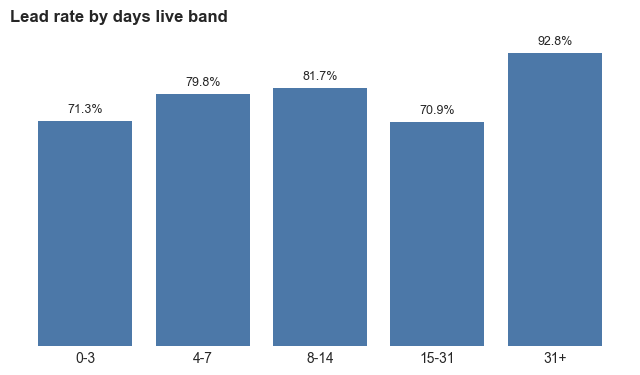

In [9]:
insight_data["days_live_band"] = pd.cut(
    insight_data["days_live"],
    bins=[-1, 3, 7, 14, 31, float("inf")],
    labels=["0-3", "4-7", "8-14", "15-31", "31+"],
)

lifecycle_summary = (
    insight_data.dropna(subset=["days_live_band"])
    .groupby("days_live_band", observed=True)
    .agg(
        ads=("src_ad_id", "count"),
        lead_rate=("has_any_lead", "mean"),
        avg_total_leads=("total_leads", "mean"),
        median_total_leads=("total_leads", "median"),
        median_price=("price", "median"),
        median_photos=("photo_cnt", "median"),
    )
    .reset_index()
)
lifecycle_summary["share_of_ads"] = lifecycle_summary["ads"] / len(insight_data)

display(helpers.style_table(lifecycle_summary))

fig, ax = helpers.plt.subplots(figsize=(8, 4))
helpers.plot_labeled_vertical_bars(
    ax,
    lifecycle_summary["days_live_band"].astype(str),
    lifecycle_summary["lead_rate"],
    "Lead rate by days live band",
    ylabel="Lead rate",
    colors=helpers.PLOT_COLORS["A"],
    percent_y=True,
    percent_labels=True,
)
helpers.plt.show()


#### 2.7.2 Start Day of Week

The start date can also be used to compare weekday posting patterns. If some start days consistently perform better, this could become seller guidance. For now, it should be read as an exploratory pattern because weekday differences may reflect inventory mix or seller behavior rather than timing alone.


,Start Weekday,Ads,Lead Rate,Avg Leads/Ad,Median Days Live,Median Price,Share of Ads
0,Monday,"27,766",0.699,4.637,31.000,"65,000.000",0.152
1,Tuesday,"33,284",0.728,5.025,31.000,"59,900.000",0.182
2,Wednesday,"28,676",0.740,5.254,31.000,"55,000.000",0.157
3,Thursday,"28,054",0.739,5.832,31.000,"59,500.000",0.153
4,Friday,"29,752",0.751,5.457,31.000,"57,500.000",0.163
5,Saturday,"22,929",0.765,5.782,31.000,"54,500.000",0.125
6,Sunday,"12,601",0.759,5.519,31.000,"60,000.000",0.069


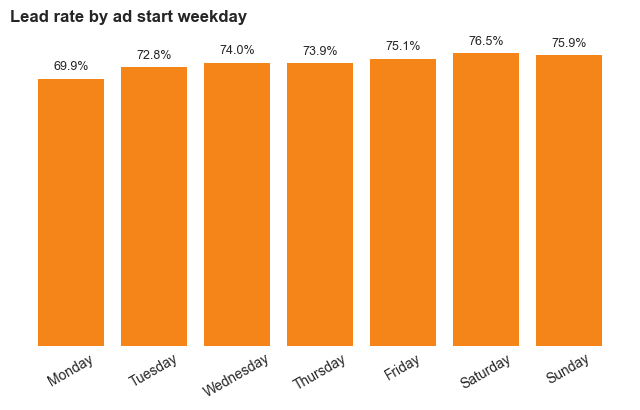

In [10]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
insight_data["start_weekday"] = insight_data["ad_start_dt"].dt.day_name()

weekday_summary = (
    insight_data.groupby("start_weekday")
    .agg(
        ads=("src_ad_id", "count"),
        lead_rate=("has_any_lead", "mean"),
        avg_total_leads=("total_leads", "mean"),
        median_days_live=("days_live", "median"),
        median_price=("price", "median"),
    )
    .reindex(weekday_order)
    .reset_index()
)
weekday_summary["share_of_ads"] = weekday_summary["ads"] / len(insight_data)

display(helpers.style_table(weekday_summary))

fig, ax = helpers.plt.subplots(figsize=(8, 4))
helpers.plot_labeled_vertical_bars(
    ax,
    weekday_summary["start_weekday"],
    weekday_summary["lead_rate"],
    "Lead rate by ad start weekday",
    ylabel="Lead rate",
    colors=helpers.PLOT_COLORS["B"],
    percent_y=True,
    percent_labels=True,
)
ax.tick_params(axis="x", rotation=30)
helpers.plt.show()


#### 2.7.3 Fresh vs Stale Listings

A practical business lens is to classify ads as fresh, mid-life, or stale. This helps identify where product nudges might be useful: fresh listings need early momentum, while older low-performing listings may need price, photo, or promotion advice.


In [11]:
insight_data["listing_lifecycle_stage"] = pd.cut(
    insight_data["days_live"],
    bins=[-1, 7, 31, float("inf")],
    labels=["Fresh: 0-7 days", "Mid-life: 8-31 days", "Stale: 31+ days"],
)

fresh_stale_summary = (
    insight_data.groupby("listing_lifecycle_stage", observed=True)
    .agg(
        ads=("src_ad_id", "count"),
        lead_rate=("has_any_lead", "mean"),
        avg_total_leads=("total_leads", "mean"),
        median_total_leads=("total_leads", "median"),
        median_price=("price", "median"),
        median_photos=("photo_cnt", "median"),
        median_mileage=("kmstand", "median"),
    )
    .reset_index()
)
fresh_stale_summary["share_of_ads"] = fresh_stale_summary["ads"] / len(insight_data)

display(helpers.style_table(fresh_stale_summary))


,Listing Lifecycle Stage,Ads,Lead Rate,Avg Leads/Ad,Median Leads/Ad,Median Price,Median Photos,Median Mileage,Share of Ads
0,Fresh: 0-7 days,"29,537",0.755,6.701,3.000,"33,500.000",13.000,"155,151.000",0.161
1,Mid-life: 8-31 days,"143,778",0.721,4.796,2.000,"66,900.000",16.000,"132,728.000",0.785
2,Stale: 31+ days,"9,747",0.928,8.951,6.000,"37,500.000",11.000,"169,399.500",0.053


#### 2.7.4 Promotion Timing

The lifecycle view can become a product use case: trigger listing advice or paid promotion offers when an ad has been live long enough to judge early performance, but before the seller gives up or the listing becomes stale.


Potential promotion-timing triggers:

- **Fresh listing with weak early leads:** suggest more photos, a stronger description, or a price check after the first few days.
- **Mid-life listing with below-segment lead rate:** recommend renewal, homepage placement, or a targeted visibility boost.
- **Stale listing with low total leads:** prompt a price adjustment, content refresh, or de-list/repost guidance.
- **High-potential listing with strong early leads:** offer premium placement while demand is already visible.

Before using this in production, I would want impressions, search rank, comparable listings, seller edit history, paid exposure history, lead quality, conversion rate, and paid-product incrementality.


### 2.8 Dataset Limitations

The dataset is useful, but the missing pieces matter. These limitations also point directly to useful joins with other public or Adevinta datasets.


Main limitations and useful joins:

- **No final sale outcome:** add transaction data, final sale price, and listing close reason.
- **No buyer journey:** add search logs, clickstream, saved ads, and buyer cohorts.
- **No seller history:** add seller tenure, response speed, ratings, and subscription/product history.
- **No search exposure or ranking data:** add impressions, search rank, recommendation placement, and paid exposure.
- **No lead quality or duplicate-lead flag:** add lead follow-up, seller response, conversion, and spam/duplicate indicators.
- **Limited causal interpretation outside q2:** add experiment metadata, exposure logs, or stronger modelling controls.


## 3. Which Ad Characteristics Relate to Leads?

These comparisons are descriptive, not causal. They show how ads with at least one lead differ from ads without leads. This is useful for identifying candidate drivers to investigate more rigorously later.


In [12]:
numeric_fields = ["price", "kmstand", "car_age", "photo_cnt", "days_live", "vermogen"]
lead_profile = (
    insight_data.groupby("has_any_lead")[numeric_fields]
    .median()
    .T
    .rename(columns={False: "no_lead_median", True: "lead_median"})
    .reset_index()
    .rename(columns={"index": "dimension"})
)
lead_profile["difference_lead_minus_no_lead"] = lead_profile["lead_median"] - lead_profile["no_lead_median"]
lead_profile["pct_difference_vs_no_lead"] = lead_profile["difference_lead_minus_no_lead"] / lead_profile["no_lead_median"]

display(helpers.style_table(lead_profile))


has_any_lead,Dimension,No Lead Median,Lead Median,Difference Lead Minus No Lead,Percent Difference vs No Lead
0,Price,"99,000.000","46,450.000","-52,550.000",-0.531
1,Mileage,"88,921.000","152,759.000","63,838.000",0.718
2,Car Age,5.000,10.000,5.000,1.000
3,Photos,18.000,14.000,-4.000,-0.222
4,Days Live,31.000,31.000,0.000,0.000
5,Power,75.000,77.000,2.000,0.027


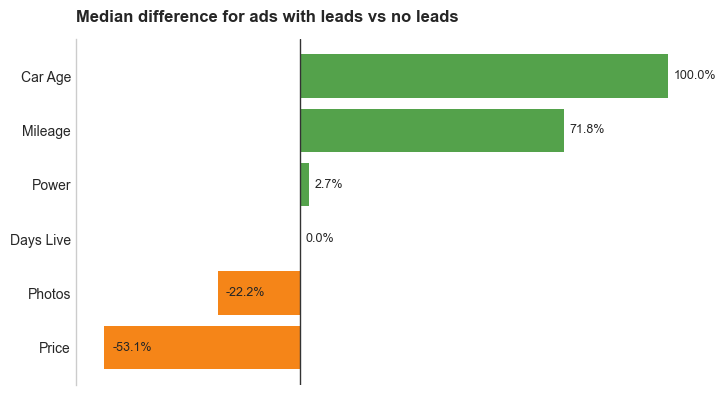

In [13]:
plot_profile = lead_profile.dropna(subset=["pct_difference_vs_no_lead"]).sort_values("pct_difference_vs_no_lead")
fig, ax = helpers.plt.subplots(figsize=(8, 4.5))
helpers.plot_labeled_horizontal_bars(
    ax,
    plot_profile["dimension"].map(helpers.DISPLAY_VALUE_ALIASES).fillna(plot_profile["dimension"]),
    plot_profile["pct_difference_vs_no_lead"],
    "Median difference for ads with leads vs no leads",
    xlabel="Percent difference",
    colors=helpers.signed_difference_colors(plot_profile["pct_difference_vs_no_lead"]),
    percent_x=True,
    percent_labels=True,
    zero_line=True,
)
helpers.plt.show()


## 4. Candidate Insights To Narrow Later

The broad first-impression pass suggests several possible storylines. I would narrow to the strongest ones after reviewing the tables and charts together.


Candidate storylines to narrow later:

- **Lead type matters:** a single any-lead KPI is good for simplicity, but product teams may care about channel quality.
- **Lead volume is skewed:** averages can be pulled by high-performing ads, so seller experience needs median and percentile views.
- **Listing quality may be actionable:** photo count and ad presentation are things sellers and product nudges can influence.
- **Vehicle segments reveal demand patterns:** price, mileage, age, body type, and brand can guide supply, merchandising, and targeting decisions.
- **This is a lead-interest dataset, not a transaction dataset:** the missing funnel pieces naturally motivate dataset joins and future analysis.


## 5. Three Business Use Cases

The dataset is most valuable when converted into repeatable decision systems. These three use cases are realistic with the current fields, and each becomes stronger if combined with additional Adevinta or public data.


1. **Seller listing optimization**

   Use the data to estimate which listing choices and car attributes are associated with lead generation, then give sellers concrete guidance on photos, pricing bands, and promotion timing. This becomes stronger with a seller/account dataset, listing edit history, image quality, local competition, and final sale outcomes.

2. **Marketplace supply and demand intelligence**

   Use the data to identify categories, brands, body types, price bands, and mileage bands with strong buyer interest, then compare demand against available supply. This becomes stronger with search demand, buyer location, public vehicle registrations, fuel prices, and regional inventory data.

3. **Commercial product targeting**

   Use the car-ad data plus a seller/account dataset to target paid visibility, lead-boosting products, or seller bundles toward SMB sellers where incremental exposure is most likely to create value. This becomes stronger with seller subscription status, product purchase history, margins, churn risk, lead quality, and downstream conversion or revenue.


## 6. Recommendation

I would keep q2 and q3 as separate notebooks. Q2 should stay focused on experiment setup, A/B comparability, the primary result, and test risks. Q3 should own the broader marketplace insight story: lead-channel behavior, skew, listing-quality signals, vehicle-demand segments, limitations, and business use cases.

Final takeaway: this data is strong for understanding and improving lead generation. It should be paired with seller, buyer, revenue, exposure, and conversion data before using it for ROI decisions, pricing policy, or causal product claims.
